--- Lab 2: MLP Hyperparameter Tuning ---
Enter hidden layer activation (relu/sigmoid) [default relu]: 
Enter learning rate (press Enter for default 0.1): 
Enter number of epochs (press Enter for default 100): 

--- Dataset Setup ---
How many total samples (rows) are in your dataset? 4
How many features (inputs) per sample? 2

Enter your data row by row.
Enter 2 features for sample 1 (space-separated): 0 0
Enter target label for sample 1 (e.g., 0 or 1): 0
-
Enter 2 features for sample 2 (space-separated): 1 0
Enter target label for sample 2 (e.g., 0 or 1): 1
-
Enter 2 features for sample 3 (space-separated): 0 1
Enter target label for sample 3 (e.g., 0 or 1): 1
-
Enter 2 features for sample 4 (space-separated): 1 1
Enter target label for sample 4 (e.g., 0 or 1): 0
-

Building MLP (Input -> Dense(8, relu) -> Dense(1, sigmoid))...
Training for 100 epochs (this may take a few seconds)...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



--- Final Results ---
Configuration : Activation = Relu, LR = 0.1
Final Loss    : 0.3481
Final Acc.    : 75%


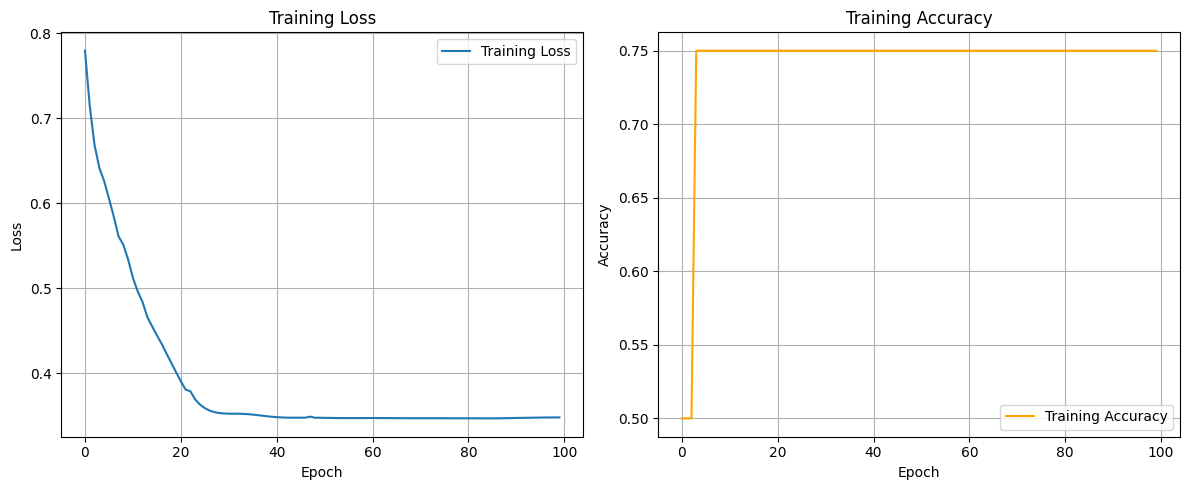

In [4]:
import os
# Suppress TensorFlow info and warning logs for a cleaner terminal
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
import matplotlib.pyplot as plt

# Set random seeds for reproducibility (helps match lab sheet results)
tf.random.set_seed(42)
np.random.seed(42)

def build_mlp(input_dim, activation='relu', lr=0.1):
    """Builds and compiles the MLP model based on Lab 2 specifications."""
    model = models.Sequential([
        layers.Dense(8, activation=activation, input_shape=(input_dim,)),
        layers.Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

def plot_training_history(history):
    """Plots the training loss and accuracy over epochs."""
    if history is None:
        print("No training history found. Please run the training cell first.")
        return

    # Get the history data
    loss = history.history['loss']
    accuracy = history.history['accuracy']
    epochs_range = range(len(loss))

    plt.figure(figsize=(12, 5))

    # Plot Loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.title('Training Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend(loc='upper right')
    plt.grid(True)

    # Plot Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, accuracy, label='Training Accuracy', color='orange')
    plt.title('Training Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend(loc='lower right')
    plt.grid(True)

    plt.tight_layout()
    plt.show()

# Global history object to store training history for plotting
global_history = None

# Main execution block
if __name__ == "__main__":
    print("--- Lab 2: MLP Hyperparameter Tuning ---")

    try:
        # 1. Get Hyperparameters
        act_input = input("Enter hidden layer activation (relu/sigmoid) [default relu]: ").strip().lower()
        activation = act_input if act_input in ['relu', 'sigmoid'] else 'relu'

        lr_input = input("Enter learning rate (press Enter for default 0.1): ")
        lr = float(lr_input) if lr_input.strip() else 0.1

        epochs_input = input("Enter number of epochs (press Enter for default 100): ")
        epochs = int(epochs_input) if epochs_input.strip() else 100

        # 2. Define Dataset Dimensions
        print("\n--- Dataset Setup ---")
        n_samples = int(input("How many total samples (rows) are in your dataset? "))
        n_features = int(input("How many features (inputs) per sample? "))

        X_list = []
        y_list = []

        # 3. Build Dataset from User Input
        print("\nEnter your data row by row.")
        for i in range(n_samples):
            # Input features for this row
            x_val = input(f"Enter {n_features} features for sample {i+1} (space-separated): ")
            row_features = [float(x) for x in x_val.strip().split()]

            if len(row_features) != n_features:
                raise ValueError(f"Expected {n_features} features, but got {len(row_features)}.")
            X_list.append(row_features)

            # Input target label for this row
            y_val = input(f"Enter target label for sample {i+1} (e.g., 0 or 1): ")
            y_list.append([float(y_val.strip())]) # Keras expects a 2D array for targets
            print("-")

        X = np.array(X_list)
        y = np.array(y_list)

        # 4. Build and Train Model
        print(f"\nBuilding MLP (Input -> Dense(8, {activation}) -> Dense(1, sigmoid))...")
        model = build_mlp(input_dim=n_features, activation=activation, lr=lr)

        print(f"Training for {epochs} epochs (this may take a few seconds)...")
        # verbose=0 hides the progress bar so it doesn't spam your terminal
        history = model.fit(X, y, epochs=epochs, verbose=0)

        # Store history in a global variable for plotting in other cells
        global_history = history

        # 5. Output Final Results
        final_loss = history.history['loss'][-1]
        final_acc = history.history['accuracy'][-1] * 100

        print("\n--- Final Results ---")
        print(f"Configuration : Activation = {activation.capitalize()}, LR = {lr}")
        print(f"Final Loss    : {final_loss:.4f}")
        print(f"Final Acc.    : {final_acc:.0f}%")

    except ValueError as e:
        print(f"\nInput Error: {e}")
        print("Please restart the script and enter valid numbers.")
    except Exception as e:
        print(f"\nAn unexpected error occurred: {e}")

# Call the plotting function with the global history object after training
plot_training_history(global_history)